# 1. Preparation
- データセットを読み込み、記述子の計算を行う
- SMILES から RDKit/Mordred 等の記述子を計算し、`../data/dataset_train.csv` / `dataset_test.csv` と `notebook/outputs/descriptors/` 以下の CSV を生成します。
- 続く `2.EDA.ipynb` 以降はこれらを入力として読みます。

---

## ユーザー設定（ここを編集してください）
**以下のセルでデータセットのパス、SMILES列、目的変数などを指定してください。**

In [ ]:
# ============================================================
# ユーザー設定: ここを編集して任意のデータセットに対応させてください
# ============================================================

# データセットのパス（CSVファイル）
DATASET_PATH = "../data/DB for chromophore_Sci_Data_rev02.csv"

# インデックスとして使用する列名（Noneの場合は自動インデックス）
INDEX_COL = 0  # 0列目をインデックスとして使用、または列名を文字列で指定

# SMILES列の名前
SMILES_COL = "Chromophore"

# 目的変数の列名（リストで複数指定可能）
TARGET_COLS = ["Emission max (nm)", "Quantum yield"]

# 学習/テストデータの分割方法
# "missing": 目的変数が全て揃っている行を学習データ、欠損がある行をテストデータ（デフォルト）
# "random": ランダムに分割（RANDOM_TEST_SIZE で割合を指定）
# "column": 特定の列の値で分割（SPLIT_COL と SPLIT_TEST_VALUE で指定）
SPLIT_METHOD = "missing"

# ランダム分割の場合のテストデータ割合（0.0〜1.0）
RANDOM_TEST_SIZE = 0.2
RANDOM_SEED = 42

# カラムベース分割の場合の設定
SPLIT_COL = None  # 分割に使用する列名
SPLIT_TEST_VALUE = None  # この値を持つ行をテストデータとする

# 出力先ディレクトリ
OUTPUT_DIR = "outputs/descriptors"

# ============================================================
# 設定の確認表示
# ============================================================
print("=" * 60)
print("設定確認")
print("=" * 60)
print(f"データセット: {DATASET_PATH}")
print(f"SMILES列: {SMILES_COL}")
print(f"目的変数: {TARGET_COLS}")
print(f"分割方法: {SPLIT_METHOD}")
print("=" * 60)

In [ ]:
# ライブラリの読み込み
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import IPython
from IPython.display import display

from rdkit import rdBase, Chem
from rdkit.Chem import AllChem, Descriptors, Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.ML.Descriptors import MoleculeDescriptors

from mordred import Calculator, descriptors

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import json
import scipy

import gc

## データ読み込み

In [ ]:
# データ読み込み（設定変数を使用）
dataset = pd.read_csv(DATASET_PATH, index_col=INDEX_COL)

print(f"データセット読み込み完了: {DATASET_PATH}")
print(f"データセット形状: {dataset.shape}")
print(f"SMILES列: {SMILES_COL}")
print(f"目的変数: {TARGET_COLS}")
display(dataset.head())

,Chromophore,Solvent,Absorption max (nm),Emission max (nm),Lifetime (ns),Quantum yield,log(e/mol-1 dm3 cm-1),abs FWHM (cm-1),emi FWHM (cm-1),abs FWHM (nm),emi FWHM (nm),Molecular weight (g mol-1),Reference
Tag,,,,,,,,,,,,,
1,N#Cc1cc2ccc(O)cc2oc1=O,O,355.0,410.00,2.804262,NaN,NaN,NaN,NaN,NaN,NaN,187.15370,DOI: 10.1021/acs.jpcb.5b09905
2,N#Cc1cc2ccc([O-])cc2oc1=O,O,408.0,450.00,3.961965,NaN,NaN,NaN,NaN,NaN,43.0,186.14576,DOI: 10.1021/acs.jpcb.5b09905
3,CCCCCCCCCCCC#CC#CCCCCCCCCCN1C(=O)c2ccc3c4ccc5c...,ClC(Cl)Cl,526.0,535.00,3.602954,NaN,NaN,NaN,NaN,NaN,NaN,1061.54348,https://doi.org/10.1002/smll.201901342
4,[O-]c1c(-c2nc3ccccc3s2)cc2ccc3cccc4ccc1c2c34,CC#N,514.0,553.72,3.810000,NaN,NaN,NaN,NaN,NaN,67.4,350.42028,https://doi.org/10.1016/j.snb.2018.10.043
5,[O-]c1c(-c2nc3ccccc3s2)cc2ccc3cccc4ccc1c2c34,CS(C)=O,524.0,555.00,4.700000,NaN,NaN,NaN,NaN,58.0,50.0,350.42028,https://doi.org/10.1016/j.snb.2018.10.043


In [ ]:
# データ分割（設定変数 SPLIT_METHOD に基づく）
from sklearn.model_selection import train_test_split

if SPLIT_METHOD == "missing":
    # 目的変数が全て揃っている行を学習データ、欠損がある行をテストデータ
    mask_train = dataset[TARGET_COLS].notnull().all(axis=1)
    dataset_train = dataset[mask_train]
    dataset_test = dataset[~mask_train]
    print(f"分割方法: missing（目的変数 {TARGET_COLS} の欠損有無で分割）")

elif SPLIT_METHOD == "random":
    # ランダム分割
    dataset_train, dataset_test = train_test_split(
        dataset, 
        test_size=RANDOM_TEST_SIZE, 
        random_state=RANDOM_SEED
    )
    print(f"分割方法: random（テスト割合: {RANDOM_TEST_SIZE}, seed: {RANDOM_SEED}）")

elif SPLIT_METHOD == "column":
    # 特定の列の値で分割
    if SPLIT_COL is None or SPLIT_TEST_VALUE is None:
        raise ValueError("SPLIT_METHOD='column' の場合、SPLIT_COL と SPLIT_TEST_VALUE を指定してください")
    dataset_test = dataset[dataset[SPLIT_COL] == SPLIT_TEST_VALUE]
    dataset_train = dataset[dataset[SPLIT_COL] != SPLIT_TEST_VALUE]
    print(f"分割方法: column（{SPLIT_COL} == {SPLIT_TEST_VALUE} をテストデータとする）")

else:
    raise ValueError(f"未知の分割方法: {SPLIT_METHOD}")

# 保存しておく
dataset_train.to_csv('../data/dataset_train.csv', index=True)
dataset_test.to_csv('../data/dataset_test.csv', index=True)

print(f"dataset.shape: {dataset.shape}")
print(f"dataset_train: {dataset_train.shape}")
print(f"dataset_test: {dataset_test.shape}")

dataset.shape: (20236, 13)
dataset_train: (13132, 13)
dataset_test: (7104, 13)


## RDKit

### 学習データ

In [ ]:
# smiles列を抽出（設定変数 SMILES_COL を使用）
smiles_train = dataset_train[SMILES_COL]

# 計算する記述子名の取得
descriptor_names = []

for descriptor_information in Descriptors.descList:
    descriptor_names.append(descriptor_information[0])

print('計算する記述子の数：', len(descriptor_names))

計算する記述子の数： 217


In [ ]:
# 記述子計算器
descriptor_calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

# 空のリストに計算結果を格納していく
descriptors_rdkit_train = []

for index, smiles_i in enumerate(smiles_train):
    print(index + 1, '/', len(smiles_train))
    mol = Chem.MolFromSmiles(smiles_i)

    # 不正なSMILESの場合はNaNを格納
    if mol is None:
        descriptors_rdkit_train.append([np.nan] * len(descriptor_names))
        continue

    descriptors_rdkit_train.append(
        descriptor_calculator.CalcDescriptors(mol)
    )

# DataFrame化（indexは dataset_train に合わせる）
descriptor_rdkit_train = pd.DataFrame(
    descriptors_rdkit_train,
    index=dataset_train.index,
    columns=descriptor_names
)

display(descriptor_rdkit_train.head())

1 / 13132
2 / 13132
3 / 13132
4 / 13132
5 / 13132
6 / 13132
7 / 13132
8 / 13132
9 / 13132
10 / 13132
11 / 13132
12 / 13132
13 / 13132
14 / 13132
15 / 13132
16 / 13132
17 / 13132
18 / 13132
19 / 13132
20 / 13132
21 / 13132
22 / 13132
23 / 13132
24 / 13132
25 / 13132
26 / 13132
27 / 13132
28 / 13132
29 / 13132
30 / 13132
31 / 13132
32 / 13132
33 / 13132
34 / 13132
35 / 13132
36 / 13132
37 / 13132
38 / 13132
39 / 13132
40 / 13132
41 / 13132
42 / 13132
43 / 13132
44 / 13132
45 / 13132
46 / 13132
47 / 13132
48 / 13132
49 / 13132
50 / 13132
51 / 13132
52 / 13132
53 / 13132
54 / 13132
55 / 13132
56 / 13132
57 / 13132
58 / 13132
59 / 13132
60 / 13132
61 / 13132
62 / 13132
63 / 13132
64 / 13132
65 / 13132
66 / 13132
67 / 13132
68 / 13132
69 / 13132
70 / 13132
71 / 13132
72 / 13132
73 / 13132
74 / 13132
75 / 13132
76 / 13132
77 / 13132
78 / 13132
79 / 13132
80 / 13132
81 / 13132
82 / 13132
83 / 13132
84 / 13132
85 / 13132
86 / 13132
87 / 13132
88 / 13132
89 / 13132
90 / 13132
91 / 13132
92 / 131

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
Tag,,,,,,,,,,,,,,,,,,,,,
72,12.408729,12.408729,0.029454,-1.347366,0.284676,11.310345,645.879,639.831,641.695969,146,...,0,0,0,0,0,0,0,0,0,0
73,12.503623,12.503623,0.021975,-1.307991,0.220631,11.310345,833.879,827.831,833.640512,146,...,0,0,0,0,0,0,0,0,0,0
74,12.637713,12.637713,0.057996,-1.632189,0.093205,11.515152,971.659,969.643,969.484623,170,...,0,0,0,0,0,0,0,0,0,0
75,12.408729,12.408729,0.029454,-1.347366,0.284676,11.310345,645.879,639.831,641.695969,146,...,0,0,0,0,0,0,0,0,0,0
76,12.503623,12.503623,0.021975,-1.307991,0.220631,11.310345,833.879,827.831,833.640512,146,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# ============================================================
# 前処理用の関数群（Mordred 記述子などでも共通利用）
# ============================================================

def _coerce_numeric_df(X: pd.DataFrame):
    """
    DataFrame の全列を数値型に変換（coerce）し、
    それでも数値化できない列を削除する。

    Returns:
        X_num : 数値型に変換後の DataFrame
        dropped_non_numeric_cols : 数値化できず削除された列名のリスト
    """
    X2 = X.copy()

    # 数値型でない列を抽出
    non_numeric_cols = X2.select_dtypes(exclude="number").columns.tolist()

    # 数値変換を試みる（変換できないものは NaN）
    for col in non_numeric_cols:
        X2[col] = pd.to_numeric(X2[col], errors="coerce")

    # それでも数値型でない列を削除
    still_non_numeric = X2.select_dtypes(exclude="number").columns.tolist()
    if len(still_non_numeric) > 0:
        X2 = X2.drop(columns=still_non_numeric, errors="ignore")

    return X2, still_non_numeric

def fit_preprocess_rule(
    X_train: pd.DataFrame,
    missing_rate_threshold: float = 0.30,
) -> dict:
    """
    学習データ（train）のみを用いて前処理ルールを決定する関数。

    処理内容：
        1. 非数値列を数値に変換し、変換できない列を削除
        2. ±inf を NaN に置換
        3. 欠損率が threshold を超える列を削除
        4. 標準偏差が 0 の列を削除
        5. 平均値が NaN になる列を削除
        6. 欠損値補完用の平均値を計算
        7. 使用する特徴量列を確定

    Returns:
        rule : 前処理ルールをまとめた辞書
    """
    if not isinstance(X_train, pd.DataFrame):
        raise TypeError("X_train は pandas DataFrame である必要があります。")

    X = X_train.copy()

    # 1) 非数値列を数値に変換し、残った非数値列を削除
    X, dropped_non_numeric_cols = _coerce_numeric_df(X)

    # 2) inf を NaN に変換
    X = X.replace([np.inf, -np.inf], np.nan)

    # 3) 欠損率が閾値を超える列を削除（train 基準）
    missing_rate = X.isna().mean(axis=0)
    drop_cols_missing = missing_rate[missing_rate > missing_rate_threshold].index.tolist()
    X2 = X.drop(columns=drop_cols_missing, errors="ignore")

    # 4) 標準偏差が 0 の列を削除（train 基準）
    std = X2.std(axis=0, skipna=True)
    drop_cols_zero_std = std[std == 0].index.tolist()
    X3 = X2.drop(columns=drop_cols_zero_std, errors="ignore")

    # 5,6) 欠損値補完用の平均値を計算
    means = X3.mean(axis=0, skipna=True)
    drop_cols_mean_nan = means[means.isna()].index.tolist()
    if len(drop_cols_mean_nan) > 0:
        X3 = X3.drop(columns=drop_cols_mean_nan, errors="ignore")
        means = X3.mean(axis=0, skipna=True)

    feature_columns = X3.columns.tolist()

    rule = {
        "missing_rate_threshold": float(missing_rate_threshold),
        "dropped_non_numeric_cols": dropped_non_numeric_cols,
        "drop_cols_missing": drop_cols_missing,
        "drop_cols_zero_std": drop_cols_zero_std,
        "drop_cols_mean_nan": drop_cols_mean_nan,
        "impute_means": means.to_dict(),
        "feature_columns": feature_columns,
    }
    return rule


def transform_with_rule(
    X_any: pd.DataFrame,
    rule: dict,
) -> pd.DataFrame:
    """
    学習データで決定した前処理ルールを、
    任意のデータ（train / validation / test）に適用する関数。

    処理内容：
        1. 非数値列を数値に変換し、残った非数値列を削除
        2. ±inf を NaN に置換
        3. 学習時に削除すると決めた列を削除
        4. 学習時の特徴量列に揃える（不足列は NaN で追加）
        5. 学習データの平均値で欠損値補完
        6. 列順を学習データと一致させて返す
    """
    if not isinstance(X_any, pd.DataFrame):
        raise TypeError("X_any は pandas DataFrame である必要があります。")

    X = X_any.copy()

    # 1) 非数値列を数値に変換し、残った非数値列を削除
    X, still_non_numeric = _coerce_numeric_df(X)

    # 2) inf を NaN に変換
    X = X.replace([np.inf, -np.inf], np.nan)

    # 3) 学習時に削除すると決めた列を削除
    drop_cols = (
        rule.get("dropped_non_numeric_cols", [])
        + rule.get("drop_cols_missing", [])
        + rule.get("drop_cols_zero_std", [])
        + rule.get("drop_cols_mean_nan", [])
    )
    drop_cols = list(dict.fromkeys(drop_cols))  # 重複除去
    X = X.drop(columns=drop_cols, errors="ignore")

    # 4) 学習時の特徴量列に合わせる
    feature_columns = rule["feature_columns"]
    missing_cols = [c for c in feature_columns if c not in X.columns]
    if len(missing_cols) > 0:
        X[missing_cols] = np.nan

    X = X[feature_columns]

    # 5) 学習データの平均値で欠損補完
    means = pd.Series(rule["impute_means"]).reindex(feature_columns)
    X = X.fillna(means)

    return X

In [ ]:
# 学習データにおける説明変数を元に前処理のルールを決定
rule_rdkit = fit_preprocess_rule(
    X_train=descriptor_rdkit_train,
    missing_rate_threshold=0.30,
)

print("=== rule_rdkit summary ===")
print("n_features (after fit):", len(rule_rdkit["feature_columns"]))
print("dropped non-numeric cols:", len(rule_rdkit["dropped_non_numeric_cols"]))
print("drop missing cols:", len(rule_rdkit["drop_cols_missing"]))
print("drop zero-std cols:", len(rule_rdkit["drop_cols_zero_std"]))
print("drop mean-NaN cols:", len(rule_rdkit["drop_cols_mean_nan"]))

=== rule_rdkit summary ===
n_features (after fit): 206
dropped non-numeric cols: 0
drop missing cols: 0
drop zero-std cols: 11
drop mean-NaN cols: 0


In [ ]:
# 学習データをtransform
X_train_rdkit_processed = transform_with_rule(descriptor_rdkit_train, rule_rdkit)

print("X_train_rdkit_processed shape:", X_train_rdkit_processed.shape)
display(X_train_rdkit_processed.head())

X_train_rdkit_processed shape: (13132, 206)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
Tag,,,,,,,,,,,,,,,,,,,,,
72,12.408729,12.408729,0.029454,-1.347366,0.284676,11.310345,645.879,639.831,641.695969,146,...,0,0,0,0,0,0,0,0,0,0
73,12.503623,12.503623,0.021975,-1.307991,0.220631,11.310345,833.879,827.831,833.640512,146,...,0,0,0,0,0,0,0,0,0,0
74,12.637713,12.637713,0.057996,-1.632189,0.093205,11.515152,971.659,969.643,969.484623,170,...,0,0,0,0,0,0,0,0,0,0
75,12.408729,12.408729,0.029454,-1.347366,0.284676,11.310345,645.879,639.831,641.695969,146,...,0,0,0,0,0,0,0,0,0,0
76,12.503623,12.503623,0.021975,-1.307991,0.220631,11.310345,833.879,827.831,833.640512,146,...,0,0,0,0,0,0,0,0,0,0


### テストデータ

In [ ]:
# smiles列を抽出（テスト、設定変数 SMILES_COL を使用）
smiles_test = dataset_test[SMILES_COL]

print("テスト分子数:", len(smiles_test))

# descriptor_names は学習時に作ったものをそのまま使う
print("記述子数:", len(descriptor_names))

# 記述子計算器
descriptor_calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

descriptors_rdkit_test = []

for index, smiles_i in enumerate(smiles_test):
    print(index + 1, '/', len(smiles_test))
    mol = Chem.MolFromSmiles(smiles_i)

    # 不正なSMILESの場合はNaNを格納
    if mol is None:
        descriptors_rdkit_test.append([np.nan] * len(descriptor_names))
        continue

    descriptors_rdkit_test.append(
        descriptor_calculator.CalcDescriptors(mol)
    )

# DataFrame化（indexは dataset_test に合わせる）
descriptor_rdkit_test = pd.DataFrame(
    descriptors_rdkit_test,
    index=dataset_test.index,
    columns=descriptor_names
)

display(descriptor_rdkit_test.head())

テスト分子数: 7104
記述子数: 217
1 / 7104
2 / 7104
3 / 7104
4 / 7104
5 / 7104
6 / 7104
7 / 7104
8 / 7104
9 / 7104
10 / 7104
11 / 7104
12 / 7104
13 / 7104
14 / 7104
15 / 7104
16 / 7104
17 / 7104
18 / 7104
19 / 7104
20 / 7104
21 / 7104
22 / 7104
23 / 7104
24 / 7104
25 / 7104
26 / 7104
27 / 7104
28 / 7104
29 / 7104
30 / 7104
31 / 7104
32 / 7104
33 / 7104
34 / 7104
35 / 7104
36 / 7104
37 / 7104
38 / 7104
39 / 7104
40 / 7104
41 / 7104
42 / 7104
43 / 7104
44 / 7104
45 / 7104
46 / 7104
47 / 7104
48 / 7104
49 / 7104
50 / 7104
51 / 7104
52 / 7104
53 / 7104
54 / 7104
55 / 7104
56 / 7104
57 / 7104
58 / 7104
59 / 7104
60 / 7104
61 / 7104
62 / 7104
63 / 7104
64 / 7104
65 / 7104
66 / 7104
67 / 7104
68 / 7104
69 / 7104
70 / 7104
71 / 7104
72 / 7104
73 / 7104
74 / 7104
75 / 7104
76 / 7104
77 / 7104
78 / 7104
79 / 7104
80 / 7104
81 / 7104
82 / 7104
83 / 7104
84 / 7104
85 / 7104
86 / 7104
87 / 7104
88 / 7104
89 / 7104
90 / 7104
91 / 7104
92 / 7104
93 / 7104
94 / 7104
95 / 7104
96 / 7104
97 / 7104
98 / 7104
99 / 7

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
Tag,,,,,,,,,,,,,,,,,,,,,
1,11.104717,11.104717,0.018850,-0.689259,0.631799,9.928571,187.154,182.114,187.026943,68,...,0,0,0,0,0,0,0,0,0,0
2,11.084309,11.084309,0.059121,-0.717037,0.568211,9.928571,186.146,182.114,186.019667,68,...,0,0,0,0,0,0,0,0,0,0
3,14.130123,14.130123,0.240638,-0.240770,0.013057,12.784810,1061.549,968.813,1060.705709,418,...,0,0,0,0,0,0,0,0,33,0
4,13.279579,13.279579,0.064638,0.064638,0.344339,12.000000,350.422,338.326,350.064509,122,...,0,0,0,0,0,1,0,0,0,0
5,13.279579,13.279579,0.064638,0.064638,0.344339,12.000000,350.422,338.326,350.064509,122,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
# 学習基準ルールを使ってテストデータをtransform
X_test_rdkit_processed = transform_with_rule(
    descriptor_rdkit_test,
    rule_rdkit
)

print("X_test_rdkit_processed shape:", X_test_rdkit_processed.shape)
display(X_test_rdkit_processed.head())

X_test_rdkit_processed shape: (7104, 206)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
Tag,,,,,,,,,,,,,,,,,,,,,
1,11.104717,11.104717,0.018850,-0.689259,0.631799,9.928571,187.154,182.114,187.026943,68,...,0,0,0,0,0,0,0,0,0,0
2,11.084309,11.084309,0.059121,-0.717037,0.568211,9.928571,186.146,182.114,186.019667,68,...,0,0,0,0,0,0,0,0,0,0
3,14.130123,14.130123,0.240638,-0.240770,0.013057,12.784810,1061.549,968.813,1060.705709,418,...,0,0,0,0,0,0,0,0,33,0
4,13.279579,13.279579,0.064638,0.064638,0.344339,12.000000,350.422,338.326,350.064509,122,...,0,0,0,0,0,1,0,0,0,0
5,13.279579,13.279579,0.064638,0.064638,0.344339,12.000000,350.422,338.326,350.064509,122,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
# 列が学習データと一致しているか確認
print("train/test column match?:", (X_train_rdkit_processed.columns == X_test_rdkit_processed.columns).all())

train/test column match?: True


In [ ]:
# 保存先ディレクトリ
os.makedirs("outputs/descriptors/rdkit", exist_ok=True)

# 前処理ルールを保存
with open("outputs/descriptors/rdkit/preprocess_rule.json", "w") as f:
    json.dump(rule_rdkit, f, indent=2)

# 説明変数の保存
X_train_rdkit_processed.to_csv(
    "outputs/descriptors/rdkit/X_train_rdkit_processed.csv",
    index=True
)

X_test_rdkit_processed.to_csv(
    "outputs/descriptors/rdkit/X_test_rdkit_processed.csv",
    index=True
)

print("saved:")
print(" - outputs/descriptors/rdkit/preprocess_rule.json")
print(" - outputs/descriptors/rdkit/X_train_rdkit_processed.csv")
print(" - outputs/descriptors/rdkit/X_test_rdkit_processed.csv")

saved:
 - outputs/descriptors/rdkit/preprocess_rule.json
 - outputs/descriptors/rdkit/X_train_rdkit_processed.csv
 - outputs/descriptors/rdkit/X_test_rdkit_processed.csv


## Fingerprint

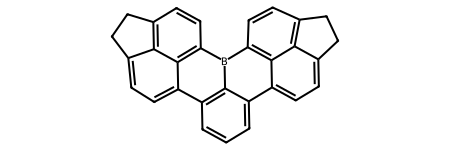

In [ ]:
# molの作成
mols_train = [Chem.MolFromSmiles(smiles_i) for smiles_i in smiles_train]

# 正しく描写できる？
mols_train[-1]

In [ ]:
# 3次元構造も見ておこう
smiles_train = [Chem.MolToSmiles(mol) for mol in mols_train]

# それぞれの方法で3次元構造を生成

def DG(mols):
    """
    ディスタンス・ジオメトリー（DG）法, 2018.03までのデフォルト方法
    """
    DG_uff = []
    mhs = [Chem.AddHs(mol) for mol in mols]
    for mol in mhs:
        AllChem.EmbedMolecule(mol,
                              useBasicKnowledge=False,
                              useExpTorsionAnglePrefs=False)
        if AllChem.UFFHasAllMoleculeParams(mol):
            AllChem.UFFOptimizeMolecule(mol)
            DG_uff.append(mol)
    return DG_uff

def ETDG(mols):
    """
    useExpTorsionAnglePrefs=True
    """
    ETDG_mols = []
    mhs = [Chem.AddHs(mol) for mol in mols]
    for mol in mhs:
        AllChem.EmbedMolecule(mol, AllChem.ETDG())
        ETDG_mols.append(mol)
    return ETDG_mols

def ETKDG(mols, version=1):
    """
    useBasicKnowledge=True
    useExpTorsionAnglePrefs=True
    2018.09以降のデフォルト方法
    """
    ETKDG_mols = []
    mhs = [Chem.AddHs(mol) for mol in mols]
    for mol in mhs:
        if version == 1:
            p = AllChem.ETKDG()
        elif version == 2:
            p = AllChem.ETKDGv2()
        elif version == 3:
            p = AllChem.ETKDGv3()
        else:
            print('invalid input')
        AllChem.EmbedMolecule(mol, p)
        ETKDG_mols.append(mol)
    return ETKDG_mols

In [ ]:
# 3D構造生成
ETKDGv1_m = ETKDG(mols_train[0:5])

# 描写
IPythonConsole.drawMol3D(ETKDGv1_m[0])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 学習データ

In [ ]:
# fingerprint を格納する list
fingerprints_train = []

# Morgan fingerprint generator（radius=2, 2048 bit）
generator = GetMorganGenerator(radius=2, fpSize=2048)

print("学習分子数:", len(mols_train))

for i, mol in enumerate(mols_train):
    print(i + 1, "/", len(mols_train))

    # mol が None の場合
    if mol is None:
        fingerprints_train.append([0] * 2048)
        continue

    try:
        fingerprint = generator.GetFingerprint(mol)
        fingerprints_train.append(list(fingerprint))
    except Exception as e:
        print("fingerprint error at index:", i, e)
        fingerprints_train.append([0] * 2048)

# numpy array
fingerprints_train_np = np.array(fingerprints_train)

# DataFrame（index は dataset_train に合わせる）
X_train_fp = pd.DataFrame(
    fingerprints_train_np,
    index=dataset_train.index,
    columns=[f"FP_{i}" for i in range(2048)]
)

print("X_train_fp shape:", X_train_fp.shape)
display(X_train_fp.head())

学習分子数: 13132
1 / 13132
2 / 13132
3 / 13132
4 / 13132
5 / 13132
6 / 13132
7 / 13132
8 / 13132
9 / 13132
10 / 13132
11 / 13132
12 / 13132
13 / 13132
14 / 13132
15 / 13132
16 / 13132
17 / 13132
18 / 13132
19 / 13132
20 / 13132
21 / 13132
22 / 13132
23 / 13132
24 / 13132
25 / 13132
26 / 13132
27 / 13132
28 / 13132
29 / 13132
30 / 13132
31 / 13132
32 / 13132
33 / 13132
34 / 13132
35 / 13132
36 / 13132
37 / 13132
38 / 13132
39 / 13132
40 / 13132
41 / 13132
42 / 13132
43 / 13132
44 / 13132
45 / 13132
46 / 13132
47 / 13132
48 / 13132
49 / 13132
50 / 13132
51 / 13132
52 / 13132
53 / 13132
54 / 13132
55 / 13132
56 / 13132
57 / 13132
58 / 13132
59 / 13132
60 / 13132
61 / 13132
62 / 13132
63 / 13132
64 / 13132
65 / 13132
66 / 13132
67 / 13132
68 / 13132
69 / 13132
70 / 13132
71 / 13132
72 / 13132
73 / 13132
74 / 13132
75 / 13132
76 / 13132
77 / 13132
78 / 13132
79 / 13132
80 / 13132
81 / 13132
82 / 13132
83 / 13132
84 / 13132
85 / 13132
86 / 13132
87 / 13132
88 / 13132
89 / 13132
90 / 13132
91 / 1

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
Tag,,,,,,,,,,,,,,,,,,,,,
72,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
73,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
74,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
75,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
76,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### テストデータ

In [ ]:
# RDKit Mol を作成
mols_test = []
for i, smi in enumerate(smiles_test):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print("Mol parse failed at index:", i)
    mols_test.append(mol)

# fingerprint を格納する list
fingerprints_test = []

# ※ generator は学習データ計算時に作ったものをそのまま使う
# generator = GetMorganGenerator(radius=2, fpSize=2048) ← 再定義しない

for i, mol in enumerate(mols_test):
    print(i + 1, "/", len(mols_test))

    # mol が None の場合
    if mol is None:
        fingerprints_test.append([0] * 2048)
        continue

    try:
        fingerprint = generator.GetFingerprint(mol)
        fingerprints_test.append(list(fingerprint))
    except Exception as e:
        print("fingerprint error at index:", i, e)
        fingerprints_test.append([0] * 2048)

# numpy array
fingerprints_test_np = np.array(fingerprints_test)

# DataFrame 化（index は dataset_test に合わせる）
X_test_fp = pd.DataFrame(
    fingerprints_test_np,
    index=dataset_test.index,
    columns=[f"FP_{i}" for i in range(2048)]
)

print("X_test_fp shape:", X_test_fp.shape)
display(X_test_fp.head())

1 / 7104
2 / 7104
3 / 7104
4 / 7104
5 / 7104
6 / 7104
7 / 7104
8 / 7104
9 / 7104
10 / 7104
11 / 7104
12 / 7104
13 / 7104
14 / 7104
15 / 7104
16 / 7104
17 / 7104
18 / 7104
19 / 7104
20 / 7104
21 / 7104
22 / 7104
23 / 7104
24 / 7104
25 / 7104
26 / 7104
27 / 7104
28 / 7104
29 / 7104
30 / 7104
31 / 7104
32 / 7104
33 / 7104
34 / 7104
35 / 7104
36 / 7104
37 / 7104
38 / 7104
39 / 7104
40 / 7104
41 / 7104
42 / 7104
43 / 7104
44 / 7104
45 / 7104
46 / 7104
47 / 7104
48 / 7104
49 / 7104
50 / 7104
51 / 7104
52 / 7104
53 / 7104
54 / 7104
55 / 7104
56 / 7104
57 / 7104
58 / 7104
59 / 7104
60 / 7104
61 / 7104
62 / 7104
63 / 7104
64 / 7104
65 / 7104
66 / 7104
67 / 7104
68 / 7104
69 / 7104
70 / 7104
71 / 7104
72 / 7104
73 / 7104
74 / 7104
75 / 7104
76 / 7104
77 / 7104
78 / 7104
79 / 7104
80 / 7104
81 / 7104
82 / 7104
83 / 7104
84 / 7104
85 / 7104
86 / 7104
87 / 7104
88 / 7104
89 / 7104
90 / 7104
91 / 7104
92 / 7104
93 / 7104
94 / 7104
95 / 7104
96 / 7104
97 / 7104
98 / 7104
99 / 7104
100 / 7104
101 / 71

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
Tag,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# 列が学習データと一致しているか確認
print(
    "train/test column match?:",
    (X_train_fp.columns == X_test_fp.columns).all()
)

train/test column match?: True


In [ ]:
# 保存先ディレクトリ
os.makedirs("outputs/descriptors/fp", exist_ok=True)

# 最低限のメタ情報
fp_meta = {
    "type": "Morgan",
    "radius": 2,
    "fpSize": 2048,
    "columns_prefix": "FP_",
}

with open("outputs/descriptors/fp/fp_meta.json", "w") as f:
    json.dump(fp_meta, f, indent=2)

# 学習データ fingerprint
X_train_fp.to_csv(
    "outputs/descriptors/fp/X_train_fp.csv",
    index=True
)

# テストデータ fingerprint
X_test_fp.to_csv(
    "outputs/descriptors/fp/X_test_fp.csv",
    index=True
)

print("saved:")
print(" - outputs/descriptors/fp/fp_meta.json")
print(" - outputs/descriptors/fp/X_train_fp.csv")
print(" - outputs/descriptors/fp/X_test_fp.csv")

saved:
 - outputs/descriptors/fp/fp_meta.json
 - outputs/descriptors/fp/X_train_fp.csv
 - outputs/descriptors/fp/X_test_fp.csv


## Mordred
- 一気にすべてのMordred記述子を計算するとkernel crashが起きるため、バッチ処理にて計算する

### 学習データ

In [ ]:
# mol file作成（バッチ処理：進捗表示・メモリ回収）
BATCH_SIZE = 200  # 必要に応じて調整（小さいほどピークメモリを抑えやすい）

# smiles列を抽出（設定変数 SMILES_COL を使用）
smiles_train = dataset_train[SMILES_COL]

# 水素なしのmolを格納するlist
mols_train = []
# 水素ありのmolを格納するlist
molhs_train = []

n_total = len(smiles_train)

for start in range(0, n_total, BATCH_SIZE):
    end = min(start + BATCH_SIZE, n_total)
    for smiles_i in smiles_train.iloc[start:end]:
        # 通常の mol
        mol = Chem.MolFromSmiles(smiles_i)
        mols_train.append(mol)

        # 3次元構造（ETKDG）
        molh = Chem.AddHs(mol)
        AllChem.EmbedMolecule(molh, AllChem.ETKDG())
        molhs_train.append(molh)

    print(f"3D 構造: {end} / {n_total} 分子")
    gc.collect()

print("完了:", len(mols_train), len(molhs_train))

3D 構造: 200 / 13132 分子
3D 構造: 400 / 13132 分子
3D 構造: 600 / 13132 分子
3D 構造: 800 / 13132 分子
3D 構造: 1000 / 13132 分子
3D 構造: 1200 / 13132 分子
3D 構造: 1400 / 13132 分子


[04:05:13] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[04:05:13] UFFTYPER: Unrecognized charge state for atom: 1
[04:05:13] UFFTYPER: Unrecognized charge state for atom: 1
[04:05:13] UFFTYPER: Warning: hybridization set to SP3 for atom 17
[04:05:13] UFFTYPER: Unrecognized charge state for atom: 1


3D 構造: 1600 / 13132 分子
3D 構造: 1800 / 13132 分子
3D 構造: 2000 / 13132 分子
3D 構造: 2200 / 13132 分子
3D 構造: 2400 / 13132 分子
3D 構造: 2600 / 13132 分子
3D 構造: 2800 / 13132 分子
3D 構造: 3000 / 13132 分子
3D 構造: 3200 / 13132 分子
3D 構造: 3400 / 13132 分子
3D 構造: 3600 / 13132 分子
3D 構造: 3800 / 13132 分子
3D 構造: 4000 / 13132 分子
3D 構造: 4200 / 13132 分子
3D 構造: 4400 / 13132 分子
3D 構造: 4600 / 13132 分子
3D 構造: 4800 / 13132 分子
3D 構造: 5000 / 13132 分子


[04:11:01] UFFTYPER: Unrecognized atom type: Se2+2 (16)
[04:11:01] UFFTYPER: Unrecognized atom type: Se2+2 (33)
[04:11:01] UFFTYPER: Unrecognized atom type: Se2+2 (50)
[04:11:02] UFFTYPER: Unrecognized atom type: Se2+2 (16)
[04:11:02] UFFTYPER: Unrecognized atom type: Se2+2 (33)
[04:11:02] UFFTYPER: Unrecognized atom type: Se2+2 (50)
[04:11:02] UFFTYPER: Unrecognized atom type: Se2+2 (67)


3D 構造: 5200 / 13132 分子


...

3D 構造: 12200 / 13132 分子
3D 構造: 12400 / 13132 分子
3D 構造: 12600 / 13132 分子
3D 構造: 12800 / 13132 分子


[06:20:20] UFFTYPER: Unrecognized charge state for atom: 10


3D 構造: 13000 / 13132 分子


[06:20:36] UFFTYPER: Unrecognized atom type: Se2+2 (10)
[06:20:36] UFFTYPER: Unrecognized atom type: Se2+2 (16)
[06:20:36] UFFTYPER: Unrecognized atom type: Se2+2 (10)
[06:20:36] UFFTYPER: Unrecognized atom type: Se2+2 (16)


3D 構造: 13132 / 13132 分子
完了: 13132 13132


In [ ]:
# 2次元記述子の計算（バッチ）
MORDRED_BATCH_SIZE = 200  # 必要に応じて調整

calc_2d = Calculator(descriptors, ignore_3D=True)
chunks_2d = []
n_mols = len(mols_train)

for start in range(0, n_mols, MORDRED_BATCH_SIZE):
    end = min(start + MORDRED_BATCH_SIZE, n_mols)
    df_b = calc_2d.pandas(mols_train[start:end])
    df_b.index = dataset_train.iloc[start:end].index
    chunks_2d.append(df_b)
    print(f"2D 記述子: {end} / {n_mols}")
    gc.collect()

df_mordred_2d_train = pd.concat(chunks_2d, axis=0)
df_mordred_2d_train.index.name = dataset_train.index.name

print(f"計算直後の2D記述子 shape: {df_mordred_2d_train.shape}")
display(df_mordred_2d_train.head())

 10%|█         | 21/200 [00:01<00:10, 16.77it/s]

/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 10%|█         | 21/200 [00:01<00:10, 16.77it/s]

/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 12%|█▏        | 23/200 [00:02<00:18,  9.61it/s]

...

 26%|██▌       | 34/132 [00:07<00:46,  2.12it/s]

/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 132/132 [01:39<00:00,  1.32it/s]


2D 記述子: 13132 / 13132
計算直後の2D記述子 shape: (13132, 1613)


,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
Tag,,,,,,,,,,,,,,,,,,,,,
72,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,...,10.630190,65.405606,641.695969,18.334171,1870,59,162.0,201.0,11.305556,6.194444
73,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,...,10.630190,65.405606,833.640512,23.818300,1870,59,162.0,201.0,11.305556,6.194444
74,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,41.40723,2.603784,5.207568,41.40723,1.254765,4.440806,...,10.833149,70.214037,969.484623,27.699561,2564,72,186.0,234.0,14.75,7.000000
75,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,...,10.630190,65.405606,641.695969,18.334171,1870,59,162.0,201.0,11.305556,6.194444
76,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,...,10.630190,65.405606,833.640512,23.818300,1870,59,162.0,201.0,11.305556,6.194444


In [ ]:
# 3次元記述子の計算（バッチ・計算時間が最も長い）
# 3D は負荷が大きい。メモリ・速度のバランスで 200〜500 程度を調整
MORDRED_BATCH_SIZE = 200

calc_3d = Calculator(descriptors, ignore_3D=False)
chunks_3d = []
n_mols = len(molhs_train)
for start in range(0, n_mols, MORDRED_BATCH_SIZE):
    end = min(start + MORDRED_BATCH_SIZE, n_mols)
    df_b = calc_3d.pandas(molhs_train[start:end])
    df_b.index = dataset_train.iloc[start:end].index
    chunks_3d.append(df_b)
    print(f"3D 記述子: {end} / {n_mols}")
    gc.collect()

df_mordred_3d_train = pd.concat(chunks_3d, axis=0)
df_mordred_3d_train.index.name = dataset_train.index.name

print(f"計算直後の3D記述子 shape: {df_mordred_3d_train.shape}")
display(df_mordred_3d_train.head())

 10%|█         | 20/200 [00:04<00:25,  6.94it/s]

/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 10%|█         | 21/200 [00:04<00:28,  6.22it/s]

/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 12%|█▏        | 23/200 [00:05<00:31,  5.71it/s]

...

 14%|█▎        | 18/132 [00:05<00:29,  3.89it/s]

/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 132/132 [00:25<00:00,  5.21it/s]


3D 記述子: 13132 / 13132
計算直後の3D記述子 shape: (13132, 1826)


,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
Tag,,,,,,,,,,,,,,,,,,,,,
72,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,...,10.630190,65.405606,641.695969,18.334171,1870,59,162.0,201.0,11.305556,6.194444
73,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,...,10.630190,65.405606,833.640512,23.818300,1870,59,162.0,201.0,11.305556,6.194444
74,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,41.40723,2.603784,5.207568,41.40723,1.254765,4.440806,...,10.833149,70.214037,969.484623,27.699561,2564,72,186.0,234.0,14.75,7.000000
75,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,...,10.630190,65.405606,641.695969,18.334171,1870,59,162.0,201.0,11.305556,6.194444
76,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,...,10.630190,65.405606,833.640512,23.818300,1870,59,162.0,201.0,11.305556,6.194444


In [ ]:
# 2D記述子の前処理
rule_mordred_2d = fit_preprocess_rule(
    X_train=df_mordred_2d_train,
    missing_rate_threshold=0.30,
)

X_train_mordred_2d_processed = transform_with_rule(
    X_any=df_mordred_2d_train,
    rule=rule_mordred_2d,
)

print("=== mordred 2D summary ===")
print("n_features:", len(rule_mordred_2d["feature_columns"]))
print("drop missing:", len(rule_mordred_2d["drop_cols_missing"]))
print("drop zero-std:", len(rule_mordred_2d["drop_cols_zero_std"]))
print("drop mean-NaN:", len(rule_mordred_2d["drop_cols_mean_nan"]))
print("dropped non-numeric:", len(rule_mordred_2d["dropped_non_numeric_cols"]))
print("processed shape:", X_train_mordred_2d_processed.shape)
print("any NaN left?:", X_train_mordred_2d_processed.isna().any().any())

=== mordred 2D summary ===
n_features: 1329
drop missing: 182
drop zero-std: 100
drop mean-NaN: 0
dropped non-numeric: 2
processed shape: (13132, 1329)
any NaN left?: False


In [ ]:
# 3D記述子の前処理
rule_mordred_3d = fit_preprocess_rule(
    X_train=df_mordred_3d_train,
    missing_rate_threshold=0.30,
)

X_train_mordred_3d_processed = transform_with_rule(
    X_any=df_mordred_3d_train,
    rule=rule_mordred_3d,
)

print("=== mordred 3D summary ===")
print("n_features:", len(rule_mordred_3d["feature_columns"]))
print("drop missing:", len(rule_mordred_3d["drop_cols_missing"]))
print("drop zero-std:", len(rule_mordred_3d["drop_cols_zero_std"]))
print("drop mean-NaN:", len(rule_mordred_3d["drop_cols_mean_nan"]))
print("dropped non-numeric:", len(rule_mordred_3d["dropped_non_numeric_cols"]))
print("processed shape:", X_train_mordred_3d_processed.shape)
print("any NaN left?:", X_train_mordred_3d_processed.isna().any().any())

=== mordred 3D summary ===
n_features: 1382
drop missing: 342
drop zero-std: 100
drop mean-NaN: 0
dropped non-numeric: 2
processed shape: (13132, 1382)
any NaN left?: False


### テストデータ

In [ ]:
# mol file作成（テストデータ）
BATCH_SIZE = 200  # 必要に応じて調整（小さいほどピークメモリを抑えやすい）

smiles_test = dataset_test[SMILES_COL]

mols_test = []
molhs_test = []

n_total = len(smiles_test)
for start in range(0, n_total, BATCH_SIZE):
    end = min(start + BATCH_SIZE, n_total)
    for smiles_i in smiles_train.iloc[start:end]:
        # 通常の mol
        mol = Chem.MolFromSmiles(smiles_i)
        mols_test.append(mol)

        # 3次元構造（ETKDG）
        molh = Chem.AddHs(mol)
        AllChem.EmbedMolecule(molh, AllChem.ETKDG())
        molhs_test.append(molh)

    print(f"3D 構造: {end} / {n_total} 分子")
    gc.collect()

print("完了:", len(mols_test), len(molhs_test))

3D 構造: 200 / 7104 分子
3D 構造: 400 / 7104 分子
3D 構造: 600 / 7104 分子
3D 構造: 800 / 7104 分子
3D 構造: 1000 / 7104 分子
3D 構造: 1200 / 7104 分子
3D 構造: 1400 / 7104 分子


[07:28:53] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[07:28:53] UFFTYPER: Unrecognized charge state for atom: 1
[07:28:54] UFFTYPER: Unrecognized charge state for atom: 1
[07:28:54] UFFTYPER: Warning: hybridization set to SP3 for atom 17
[07:28:54] UFFTYPER: Unrecognized charge state for atom: 1


3D 構造: 1600 / 7104 分子
3D 構造: 1800 / 7104 分子
3D 構造: 2000 / 7104 分子
3D 構造: 2200 / 7104 分子
3D 構造: 2400 / 7104 分子
3D 構造: 2600 / 7104 分子
3D 構造: 2800 / 7104 分子
3D 構造: 3000 / 7104 分子
3D 構造: 3200 / 7104 分子
3D 構造: 3400 / 7104 分子
3D 構造: 3600 / 7104 分子
3D 構造: 3800 / 7104 分子
3D 構造: 4000 / 7104 分子
3D 構造: 4200 / 7104 分子
3D 構造: 4400 / 7104 分子
3D 構造: 4600 / 7104 分子
3D 構造: 4800 / 7104 分子
3D 構造: 5000 / 7104 分子


[07:34:29] UFFTYPER: Unrecognized atom type: Se2+2 (16)
[07:34:29] UFFTYPER: Unrecognized atom type: Se2+2 (33)
[07:34:29] UFFTYPER: Unrecognized atom type: Se2+2 (50)
[07:34:29] UFFTYPER: Unrecognized atom type: Se2+2 (16)
[07:34:29] UFFTYPER: Unrecognized atom type: Se2+2 (33)
[07:34:29] UFFTYPER: Unrecognized atom type: Se2+2 (50)
[07:34:29] UFFTYPER: Unrecognized atom type: Se2+2 (67)


3D 構造: 5200 / 7104 分子


...

3D 構造: 6400 / 7104 分子


[07:36:19] UFFTYPER: Warning: hybridization set to SP3 for atom 14
[07:36:19] UFFTYPER: Warning: hybridization set to SP3 for atom 4
[07:36:19] UFFTYPER: Warning: hybridization set to SP3 for atom 26
[07:36:19] UFFTYPER: Warning: hybridization set to SP3 for atom 35


3D 構造: 6600 / 7104 分子
3D 構造: 6800 / 7104 分子


[07:37:24] UFFTYPER: Unrecognized atom type: Se2+2 (4)
[07:37:24] UFFTYPER: Unrecognized atom type: Se2+2 (19)
[07:37:24] UFFTYPER: Unrecognized atom type: Se2+2 (4)
[07:37:24] UFFTYPER: Unrecognized atom type: Se2+2 (27)
[07:37:24] UFFTYPER: Unrecognized atom type: Se2+2 (13)
[07:37:24] UFFTYPER: Unrecognized atom type: Se2+2 (31)


3D 構造: 7000 / 7104 分子
3D 構造: 7104 / 7104 分子
完了: 7104 7104


In [ ]:
# テストデータの記述子計算
MORDRED_BATCH_SIZE_2D = 200
MORDRED_BATCH_SIZE_3D = 200

# 1) Mordred 2D（バッチ）
calc_2d = Calculator(descriptors, ignore_3D=True)
chunks_2d_t = []
n_test = len(mols_test)
for start in range(0, n_test, MORDRED_BATCH_SIZE_2D):
    end = min(start + MORDRED_BATCH_SIZE_2D, n_test)
    df_b = calc_2d.pandas(mols_test[start:end])
    df_b.index = dataset_test.iloc[start:end].index
    chunks_2d_t.append(df_b)
    print(f"2D test: {end} / {n_test}")
    gc.collect()

df_mordred_2d_test = pd.concat(chunks_2d_t, axis=0)
df_mordred_2d_test.index.name = dataset_test.index.name

print("raw Mordred 2D (test) shape:", df_mordred_2d_test.shape)
display(df_mordred_2d_test.head())

# 2) Mordred 3D（バッチ）
calc_3d = Calculator(descriptors, ignore_3D=False)
chunks_3d_t = []
n_h = len(molhs_test)
for start in range(0, n_h, MORDRED_BATCH_SIZE_3D):
    end = min(start + MORDRED_BATCH_SIZE_3D, n_h)
    df_b = calc_3d.pandas(molhs_test[start:end])
    df_b.index = dataset_test.iloc[start:end].index
    chunks_3d_t.append(df_b)
    print(f"3D test: {end} / {n_h}")
    gc.collect()

df_mordred_3d_test = pd.concat(chunks_3d_t, axis=0)
df_mordred_3d_test.index.name = dataset_test.index.name

print("raw Mordred 3D (test) shape:", df_mordred_3d_test.shape)
display(df_mordred_3d_test.head())

 11%|█         | 22/200 [00:01<00:13, 13.64it/s]

/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 11%|█         | 22/200 [00:01<00:13, 13.64it/s]

/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 24%|██▎       | 47/200 [00:07<01:20,  1.91it/s]

...

100%|██████████| 200/200 [00:15<00:00, 12.71it/s]


3D test: 7000 / 7104


100%|██████████| 104/104 [00:04<00:00, 22.85it/s]


3D test: 7104 / 7104
raw Mordred 3D (test) shape: (7104, 1826)


,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
Tag,,,,,,,,,,,,,,,,,,,,,
1,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,...,10.630190,65.405606,641.695969,18.334171,1870,59,162.0,201.0,11.305556,6.194444
2,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,...,10.630190,65.405606,833.640512,23.818300,1870,59,162.0,201.0,11.305556,6.194444
3,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,41.40723,2.603784,5.207568,41.40723,1.254765,4.440806,...,10.833149,70.214037,969.484623,27.699561,2564,72,186.0,234.0,14.75,7.000000
4,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,...,10.630190,65.405606,641.695969,18.334171,1870,59,162.0,201.0,11.305556,6.194444
5,module 'numpy' has no attribute 'float'.\n`np....,module 'numpy' has no attribute 'float'.\n`np....,2,0,37.051229,2.579777,5.159555,37.051229,1.277629,4.315072,...,10.630190,65.405606,833.640512,23.818300,1870,59,162.0,201.0,11.305556,6.194444


In [ ]:
# 2D記述子の前処理（テストデータ）
X_test_mordred_2d_processed = transform_with_rule(
    X_any=df_mordred_2d_test,
    rule=rule_mordred_2d,
)

print("X_test_mordred_2d_processed shape:", X_test_mordred_2d_processed.shape)
print("any NaN left?:", X_test_mordred_2d_processed.isna().any().any())
print("any inf left?:", np.isinf(X_test_mordred_2d_processed.to_numpy()).any())

# 列一致チェック
print(
    "2D columns match train?:",
    (X_train_mordred_2d_processed.columns == X_test_mordred_2d_processed.columns).all())

X_test_mordred_2d_processed shape: (7104, 1329)
any NaN left?: False
any inf left?: False
2D columns match train?: True


In [ ]:
# 3D記述子の前処理（テストデータ）
X_test_mordred_3d_processed = transform_with_rule(
    X_any=df_mordred_3d_test,
    rule=rule_mordred_3d,
)

print("X_test_mordred_3d_processed shape:", X_test_mordred_3d_processed.shape)
print("any NaN left?:", X_test_mordred_3d_processed.isna().any().any())
print("any inf left?:", np.isinf(X_test_mordred_3d_processed.to_numpy()).any())

# 列一致チェック
print(
    "3D columns match train?:",
    (X_train_mordred_3d_processed.columns == X_test_mordred_3d_processed.columns).all()
)

X_test_mordred_3d_processed shape: (7104, 1382)
any NaN left?: False
any inf left?: False
3D columns match train?: True


In [ ]:
# 2D
os.makedirs("outputs/descriptors/mordred_2d", exist_ok=True)

# 説明変数の保存
X_train_mordred_2d_processed.to_csv(
    "outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv",
    index=True
)

X_test_mordred_2d_processed.to_csv(
    "outputs/descriptors/mordred_2d/X_test_mordred_2d_processed.csv",
    index=True
)

# ruleの保存
with open("outputs/descriptors/mordred_2d/preprocess_rule.json", "w") as f:
    json.dump(rule_mordred_2d, f, indent=2)

print("saved mordred_2d:")
print(" - outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv")
print(" - outputs/descriptors/mordred_2d/X_test_mordred_2d_processed.csv")
print(" - outputs/descriptors/mordred_2d/preprocess_rule.json")


# 3D
os.makedirs("outputs/descriptors/mordred_3d", exist_ok=True)

# 説明変数の保存
X_train_mordred_3d_processed.to_csv(
    "outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv",
    index=True
)

X_test_mordred_3d_processed.to_csv(
    "outputs/descriptors/mordred_3d/X_test_mordred_3d_processed.csv",
    index=True
)

# ruleの保存
with open("outputs/descriptors/mordred_3d/preprocess_rule.json", "w") as f:
    json.dump(rule_mordred_3d, f, indent=2)

print("saved mordred_3d:")
print(" - outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv")
print(" - outputs/descriptors/mordred_3d/X_test_mordred_3d_processed.csv")
print(" - outputs/descriptors/mordred_3d/preprocess_rule.json")

saved mordred_2d:
 - outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv
 - outputs/descriptors/mordred_2d/X_test_mordred_2d_processed.csv
 - outputs/descriptors/mordred_2d/preprocess_rule.json
saved mordred_3d:
 - outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv
 - outputs/descriptors/mordred_3d/X_test_mordred_3d_processed.csv
 - outputs/descriptors/mordred_3d/preprocess_rule.json
